**Notebook Feito por:** MSc. Eng. Paulo de Souza Silva  
**Data:** Agosto de 2026  
**Conteúdo retirado e adaptado de livros e artigos sobre Galerkin Descontínuo**  
**Agradecimentos:** Um agradecimento ao Prof. Dr. Alberto Nogueira pela disponibilização dos scripts em Python para DG 1D

# **Integradores Numéricos**

Nas aulas anteriores, dedicamos um esforço considerável para construir e entender cada engrenagem da nossa discretização espacial. Passamos pela base polinomial, pelas quadraturas de integração, invertemos a matriz de massa, aplicamos a projeção de fluxos para controlar o aliasing e garantimos a comunicação entre os elementos através dos fluxos numéricos nas fronteiras.O resultado de todo esse trabalho culminou em uma única e poderosa expressão computacional, o nosso operador espacial $L_h$:

$$L_h = \frac{1}{J_e} \left[\int_{\Omega_{pd}} \phi_i \phi_j d \xi \right]^{-1} \left ( \int_{\Omega_{pd}} f \dfrac{\partial}{\partial \xi} \begin{Bmatrix} \phi_0 \\ \phi_1 \\ \vdots \\ \phi_P \end{Bmatrix} d \xi-  \tilde{f}_{e,e+1} \begin{Bmatrix} \phi^+_0 \\ \phi^+_1 \\ \vdots \\ \phi^+_P \end{Bmatrix} +  \tilde{f}_{e-1,e}\begin{Bmatrix} \phi^-_0 \\ \phi^-_1 \\ \vdots \\ \phi^-_P \end{Bmatrix} \right )$$

> **Mas o que fazemos com isso agora?**

Se observarmos atentamente, ao resolver as integrais espaciais, nós eliminamos a dependência contínua da variável espacial $x$ (ou $\xi$). O que nos resta é a variação dos nossos graus de liberdade (os coeficientes $\{c_i\}$) exclusivamente no tempo.

Isso significa que transformamos a nossa Equação Diferencial Parcial (EDP) original em um gigantesco sistema acoplado de Equações Diferenciais Ordinárias (EDOs). Se definirmos o vetor de coeficientes do nosso sistema como $\mathbf{U} = \{c_0, c_1, \dots, c_P\}^T$, podemos reescrever a equação governante de forma incrivelmente compacta:

$$\frac{d\mathbf{U}}{dt} = L_h(\mathbf{U}, t)$$

Este conceito é conhecido como Método das Linhas (Method of Lines). A beleza dessa abordagem é a separação de interesses: a partir deste ponto, o integrador temporal é "cego" em relação à física. Ele não precisa saber se $\mathbf{U}$ representa a Equação de Burgers invíscida, as Equações de Euler ou uma simples equação de advecção escalar. Toda a física, as condições de contorno e o tratamento de choques estão encapsulados dentro da "caixa preta" chamada $L_h$.Nosso objetivo agora é avançar o vetor de coeficientes $\mathbf{U}$ de um tempo $t^n$ para um tempo futuro $t^{n+1} = t^n + \Delta t$.

## **Método de Euler**

### **Introdução ao Método de Euler**

A forma mais intuitiva de avançar no tempo é olhar para a definição mais fundamental do cálculo: a expansão em Série de Taylor. Se conhecemos o estado do nosso sistema em um tempo $t^n$, o estado num pequeno instante futuro $t^{n+1} = t^n + \Delta t$ pode ser escrito como:

$$\mathbf{U}(t^{n+1}) = \mathbf{U}(t^n) + \Delta t \frac{d\mathbf{U}}{dt}\bigg\vert{}_{t^n} + \frac{\Delta t^2}{2!} \frac{d^2\mathbf{U}}{dt^2}\bigg\vert{}_{t^n} + \mathcal{O}(\Delta t^3)$$

Se assumirmos que o nosso passo de tempo $\Delta t$ é suficientemente pequeno, os termos de alta ordem ($\Delta t^2$, $\Delta t^3 \dots$) tornam-se desprezíveis. Ao truncarmos a série no termo linear, obtemos o clássico Método de Euler (Explícito).

Lembrando que no nosso método DG a derivada temporal é exatamente o nosso operador espacial computado no instante atual $\left( \frac{d\mathbf{U}}{dt} = L_h(\mathbf{U}^n) \right)$, chegamos à expressão:

$$\mathbf{U}^{n+1} = \mathbf{U}^n + \Delta t L_h(\mathbf{U}^n)$$

Em termos dos coeficientes que apresentamos na Aula 00, isso equivale a escrever:

$$\{c_i\}^{(t+\Delta t)} = \{c_i\}^{(t)} + \Delta t \partial_t \{c_i\}^{(t)}$$

### **Exemplo com Método de Euler**

Para entendermos os limites da nossa primeira ferramenta de integração, vamos dar um passo atrás e esquecer temporariamente os polinômios, matrizes de massa e rigidez. Vamos resolver na mão um problema escalar simples:

$$\frac{dy}{dt} = y \hspace{1cm} \text{com condição inicial} \hspace{1cm} y(0) = 1$$

A solução analítica exata dessa Equação Diferencial Ordinária (EDO) é conhecida: 

$$y_{exato}(t) = e^t$$

Nosso objetivo é descobrir o valor da solução no instante $t = 4.0$ usando o Método de Euler com um **passo de tempo** $\Delta t = 0.5$.

Nesta analogia simples, o nosso "operador espacial" avalia apenas a própria variável: $L_h(y^n) = y^n$.

---
**Passo 0 (Condição Inicial):**  
$$ t_0 = 0.0 \hspace{3cm} y_0 = 1.0 $$

---
**Passo 1 (Avançando para $t = 0.5$):**  
Avaliamos o operador:

$$ L_h(y_0) = y_0 = 1.0 $$

Aplicamos Euler: 

$$y_1 = y_0 + \Delta t \cdot L_h (y_0) $$

o que desenvolvendo:

$$ y_1 = 1.0 + 0.5 \cdot (1.0) = \mathbf{1.5} $$

(Solução Exata seria $e^{0.5} \approx 1.6487$)  

---
**Passo 2 (Avançando para $t = 1.0$):**  

Avaliamos o operador: 
$$L_h(y_1) = y_1 = 1.5$$

Aplicamos Euler: 
$$ y_2 = y_1 + \Delta t \cdot L_h(y_1) $$

o que desenvolvendo:
$$y_2 = 1.5 + 0.5 \cdot (1.5) = \mathbf{2.25}$$

(Solução Exata seria $e^{1.0} \approx 2.7182$)

---

A ideia é prosseguir nos passos até chegarmos no valor de $t = 4.0$. 

Um código simples pode nos ajudar a calcular os demais valores do método e do erro absoluto.


In [1]:
import numpy as np
delta_t = 0.5
x = np.linspace(0,4,int(4/delta_t)+1)
y = np.zeros(len(x))

for i in range(len(x)):
    if i == 0:
        y[i] = 1
    else:
        y[i] = y[i-1] + delta_t*y[i-1]

#print(np.exp(x))
#print(y)
#print(np.abs(y-np.exp(x))) 

A Tabela a seguir sumariza os valores

<div align="center">

Tempo (t) |Numérico (Euler) | Exato (et) | Erro Absoluto $\|y_{num} - y_{exato}\|$ |
|:----:|:----:|:----:|:----:|
0.0 | 1.000   | 1.0000  | 0.0000 |
0.5 | 1.500   | 1.6487  | 0.1487 |
1.0 | 2.250   | 2.7182  | 0.4682 |
1.5 | 3.375   | 4.4817  | 1.1067 |
2.0 | 5.0625  | 7.3891  | 2.3266 |
2.5 | 7.59375 | 12.1825 | 4.5887 |
3.0 | 11.3906 | 20.0855 | 8.6949 |
3.5 | 17.0859 | 33.1155 |16.0295 |
4.0 | 25.6289 | 54.5982 |28.9692 |

</div>

**Ordem de Precisão:** Repare no Erro Absoluto. O método de Euler assume que a inclinação (derivada) da função permanece constante durante todo o intervalo $\Delta t$. Se avaliarmos outros valores de $\Delta t$ podemos notar como o erro absoluto se modifica (fonte: Wikipedia)

<div align="center">

|Intervalos | Método de Euler | Erro Absoluto |
|:-----:|:-----:|:-----:|
|1	|16.00	| 38.60 |
|0.25 |	35.53 |	19.07 |
|0.1 |	45.26 |	9.34 |
|0.05 |	49.56 |	5.04 |
|0.025 | 51.98 | 2.62 |
|0.0125	| 53.26 | 1.34 |

</div>

Como a função $e^t$ é curva (acelera com o tempo), o método de Euler fica sistematicamente "atrasado", gerando um erro de truncamento acumulado. Por truncar a série de Taylor no primeiro termo, Euler é um método de 1ª Ordem, ou seja, o erro global escala linearmente com $\mathcal{O}(\Delta t)$.

Apesar dessa precisão mais baixa e de possuir uma região de estabilidade estreita, no Método de Galerkin Descontínuo nós não descartamos o Método de Euler.

Em problemas reais de fluidodinâmica e leis de conservação hiperbólicas, a própria física do escoamento nos obriga a calcular e utilizar um $\Delta t$ extremamente restrito - ditado pela Condição CFL (Courant-Friedrichs-Lewy) - para garantir que a informação física (como a propagação de uma onda de choque) não salte elementos inteiros da malha em um único passo. Ao utilizarmos um $\Delta t$ rigorosamente ajustado à malha geométrica, o erro de truncamento do método de Euler é fortemente mitigado.

Além disso, a verdadeira estabilidade do nosso solver não dependerá exclusivamente do integrador temporal, mas da aplicação de Corretores Espaciais (**Slope Limiters**). Como veremos em detalhes em aulas futuras, logo após o passo temporal do Euler, nós interceptamos a solução e aplicamos limitadores diretamente nos coeficientes modais para suprimir oscilações espúrias antes que elas avancem no tempo.

Assim, o Euler Explícito atua como um bloco construtor servindo tanto como integrador direto (quando acoplado a limitadores de inclinação rigorosos) quanto como a base matemática que nos permitirá construir os poderosos métodos SSP (Runge-Kutta) que estudaremos a seguir.

### **Codando o Método de Euler**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, List, Optional

def Euler_Step(U_modal: List[np.ndarray], t: float, dt: float, 
    Lh_operator: Callable, 
    limiter_func: Optional[Callable] = None) -> List[np.ndarray]:
    """
    Avança a solução em um passo de tempo usando o Método de Euler Explícito.
    
    Parâmetros:
    ----------
    U_modal : List[np.ndarray]
        Lista contendo os coeficientes modais (graus de liberdade) do estado atual.
        Pode conter 1 variável (ex: Burgers) ou N variáveis (ex: Equações de Euler).
    t : float
        Tempo atual da simulação.
    dt : float
        Tamanho do passo de tempo (calculado via CFL).
    Lh_operator : Callable
        Função que representa o Operador Espacial DG. 
        Deve possuir a assinatura: Lh(U_modal, t) -> List[np.ndarray]
    limiter_func : Callable, opcional
        Função para aplicar o Slope Limiter na solução. 
        Deve possuir a assinatura: limiter(variavel_modal) -> np.ndarray
        
    Retorna:
    -------
    U_new : List[np.ndarray]
        Lista com as variáveis de estado atualizadas no tempo t + dt.
    """
    # 1. Avalia o operador espacial (Derivada no tempo)
    dU = Lh_operator(U_modal, t)
    
    # 2. Avança no tempo para cada equação do sistema
    U_new = []
    for u, du in zip(U_modal, dU):
        u_next = u + dt * du
        U_new.append(u_next)
        
    # 3. Aplica Corretores Espaciais (Slope Limiters), se fornecidos
    if limiter_func is not None:
        for i in range(len(U_new)):
            U_new[i] = limiter_func(U_new[i])
            
    return U_new

#### **Testando o código**

Para testar o nosso código vamos resolver três problemas:

**Problema 1**

$$\frac{dy}{dt} = y \hspace{2cm} y_0 = 1 \hspace{2cm}  y_{exato} = e^t$$

**Problema 2**

$$\frac{dy}{dt} = y(1-y) \hspace{2cm} y_0 = 0.1 \hspace{2cm} y_{exato} = \dfrac{1}{1 + 9e^{-t}}$$

**Problema 3**
$$y'' + 5y' - 10y = sin(t) \hspace{2cm} y_0 = 2 \ ; \ y'_0 = 4 \\ 
y_{exato} = \left( \frac{297}{292} + \frac{2675}{292\sqrt{65}} \right) e^{\left(\frac{-5 + \sqrt{65}}{2}\right)t} + \left( \frac{297}{292} - \frac{2675}{292\sqrt{65}} \right) e^{\left(\frac{-5 - \sqrt{65}}{2}\right)t} - \frac{5}{146} \cos(t) - \frac{11}{146} \sin(t)$$

In [3]:
# ====================================================================
# 2. CATÁLOGO DE PROBLEMAS (Agora devolvem a solução exata)
# ====================================================================
def setup_exponencial():
    """ Crescimento Exponencial: dy/dt = y """
    U0 = [np.array([1.0])]
    
    def Lh(U_modal, t):
        return [U_modal[0]]
        
    def sol_exata(t):
        return np.exp(t)
        
    return U0, Lh, sol_exata

import numpy as np

def setup_logistico():
    """ Problema 2: Crescimento Logístico (dy/dt = y*(1-y), y(0)=0.1) """
    U0 = [np.array([0.1])]
    
    def Lh(U_modal, t):
        y = U_modal[0]
        return [y * (1.0 - y)]
        
    def sol_exata(t):
        # Solução analítica: y(t) = 1 / (1 + 9*e^(-t))
        return 1.0 / (1.0 + 9.0 * np.exp(-t))
        
    return U0, Lh, sol_exata

def setup_sistema_edo():
    """ Sistema EDO 2ª Ordem: y'' + 5y' - 10y = sin(t) """
    # U0 = [posição y, velocidade y']
    U0 = [np.array([2.0]), np.array([4.0])]
    
    def Lh(U_modal, t):
        x1 = U_modal[0]
        x2 = U_modal[1]
        return [x2, -5.0 * x2 + 10.0 * x1 + np.sin(t)]
        
    def sol_exata(t_array):
        # Solução exata analítica que deduzimos
        r65 = np.sqrt(65.0)
        r1 = (-5.0 + r65) / 2.0
        r2 = (-5.0 - r65) / 2.0
        c1 = (297.0 / 292.0) + (2675.0 / (292.0 * r65))
        c2 = (297.0 / 292.0) - (2675.0 / (292.0 * r65))
        
        y = (c1 * np.exp(r1 * t_array) + 
             c2 * np.exp(r2 * t_array) - 
             (5.0 / 146.0) * np.cos(t_array) - 
             (11.0 / 146.0) * np.sin(t_array))
        return y
        
    return U0, Lh, sol_exata

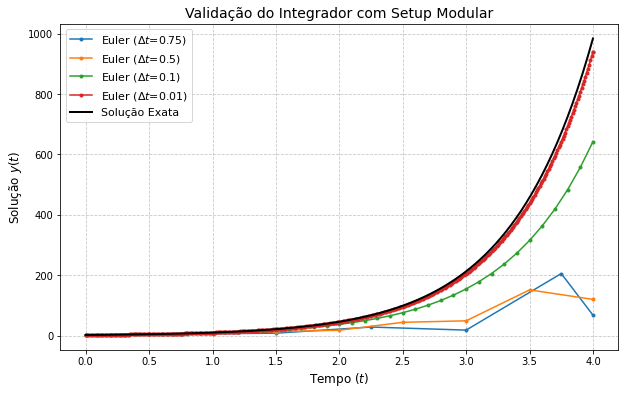

In [4]:
# ====================================================================
# 3. O LOOP DE SIMULAÇÃO SUPER MODULAR
# ====================================================================
t_inicial = 0.0
t_final = 4.0
passos_dt = [0.75, 0.5, 0.1, 0.01] 

plt.figure(figsize=(10, 6))

# Escolha o problema AQUI! O resto do código não muda.
#U0_base, Lh, sol_exata = setup_exponencial()
# U0_base, Lh, sol_exata = setup_logistico()
U0_base, Lh, sol_exata = setup_sistema_edo()

for dt_teste in passos_dt:
    
    # Precisamos de uma cópia limpa da condição inicial para cada teste de dt
    U = [u.copy() for u in U0_base]
    
    t = t_inicial
    dt = dt_teste
    
    historico_t = [t]
    # Guardamos sempre a variável primária (índice 0)
    historico_y = [U[0][0]]
    
    while t < t_final:
        if t + dt > t_final:
            dt = t_final - t
            
        U = Euler_Step(U, t, dt, Lh)
        t += dt
        
        historico_t.append(t)
        historico_y.append(U[0][0])
        
    plt.plot(historico_t, historico_y, marker='o', markersize=3, label=f'Euler ($\Delta t$={dt_teste})')

# Estética
# Plot da solução analítica de forma genérica
t_plot = np.linspace(t_inicial, t_final, 100)
plt.plot(t_plot, sol_exata(t_plot), 'k-', linewidth=2, label='Solução Exata')
plt.title('Validação do Integrador com Setup Modular', fontsize=14)
plt.xlabel('Tempo ($t$)', fontsize=12)
plt.ylabel('Solução $y(t)$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.show()

## **Runge-Kutta 4**

Para contornar as severas limitações de precisão do método de Euler explícito, o padrão ouro na integração de EDOs suaves é a família de métodos de Runge-Kutta. O mais famoso e amplamente adotado deles é o RK4 Clássico.

Ao invés de dar um salto cego usando apenas a derivada do início do passo (como faz Euler), o RK4 "sonda" a trajetória da função em pontos intermediários antes de dar o passo definitivo. Matematicamente, para ir do instante $t^n$ para $t^{n+1}$, o método avalia o operador espacial quatro vezes:

$$\begin{align*}  k_1 &= L_h(\mathbf{U}^n) \\  k_2 &= L_h\left(\mathbf{U}^n + \frac{\Delta t}{2} k_1\right) \\  k_3 &= L_h\left(\mathbf{U}^n + \frac{\Delta t}{2} k_2\right) \\  k_4 &= L_h(\mathbf{U}^n + \Delta t k_3)  \end{align*}$$

A Intuição Geométrica dos Estágios:
* $k_1$: É a inclinação no início do intervalo (exatamente o método de Euler).
* $k_2$: É a inclinação no ponto médio do intervalo, usando a inclinação $k_1$ para "adivinhar" o valor da solução no meio do caminho.
* $k_3$: É uma nova inclinação no ponto médio, mas agora usando a inclinação $k_2$ (que é melhor que $k_1$) para recalcular o estado intermediário.
* $k_4$: É a inclinação no final do intervalo, estimando o estado final através da inclinação $k_3$.

Após avaliar essas quatro "inclinações", o passo definitivo no tempo é dado por uma média ponderada estritamente inspirada na Regra de Simpson de integração numérica, dando maior peso (peso 2) às avaliações centrais:

$$\mathbf{U}^{n+1} = \mathbf{U}^n + \frac{\Delta t}{6} (k_1 + 2k_2 + 2k_3 + k_4)$$

### **Exemplo com RK4**

Para vermos o abismo de diferença entre a 1ª e a 4ª ordem de precisão, vamos aplicar o RK4 no mesmo problema escalar que usamos para o método de Euler:

$$\frac{dy}{dt} = y \hspace{1cm} \text{com} \hspace{1cm} y(0) = 1.0$$

O nosso operador espacial continua sendo $L_h(y^n) = y^n$.

Vamos tentar avançar um único e gigantesco passo de tempo $\Delta t = 0.5$.

**Passo 1 (Sondando o intervalo):**
* $k_1 = L_h(1.0) = \mathbf{1.0}$
* $k_2 = L_h(1.0 + 0.25 \times 1.0) = L_h(1.25) = \mathbf{1.25}$
* $k_3 = L_h(1.0 + 0.25 \times 1.25) = L_h(1.3125) = \mathbf{1.3125}$
* $k_4 = L_h(1.0 + 0.5 \times 1.3125) = L_h(1.65625) = \mathbf{1.65625}$

Avanço no Tempo:

$$ y_1 = y_0 + \frac{0.5}{6} \left[ 1.0 + 2(1.25) + 2(1.3125) + 1.65625 \right]$$

$$y_1 = 1.0 + \frac{0.5}{6} \left[ 7.78125 \right] = 1.0 + 0.6484375 = \mathbf{1.6484375}$$

<div align="center">

| Método | Passo (Δt) | Valor Calculado| Valor Exato $(e^{0.5})$| Erro Absoluto|
|:-----:|:-----:|:-----:|:-----:|:-----:|
|Euler (1ª Ordem)|0.5 |1.5000000 |1.6487213 | 0.1487213 |
|RK4 (4ª Ordem)| 0.5 | 1.6484375| 1.6487213 | 0.0002838 |

</div>

Vamos gerar o resto da tabela até o tempo $t = 4$ com simples código para avaliarmos a precisão do RK4

In [5]:
import numpy as np

delta_t = 0.5
t = np.linspace(0, 4, int(4/delta_t) + 1)
y = np.zeros(len(t))

# Cabeçalho da tabela em Markdown
print("| Tempo (t) | Numérico (RK4) | Exato ($e^t$) | Erro Absoluto $\|y_{num} - y_{exato}\|$ |")
print("|:----:|:----:|:----:|:----:|")

for i in range(len(t)):
    if i == 0:
        y[i] = 1.0
    else:
        # Nossa EDO: dy/dt = Lh(y) = y
        # Avaliando os 4 estágios baseados no valor do passo anterior y[i-1]
        k1 = y[i-1]
        k2 = y[i-1] + (delta_t / 2.0) * k1
        k3 = y[i-1] + (delta_t / 2.0) * k2
        k4 = y[i-1] + delta_t * k3
        
        # Avançando no tempo
        y[i] = y[i-1] + (delta_t / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    
    # Calculando a solução exata e o erro
    y_exato = np.exp(t[i])
    erro = abs(y[i] - y_exato)
    
    # Print formatado para a tabela (com 5 casas decimais de precisão)
    print(f"| {t[i]:.1f} | {y[i]:.5f} | {y_exato:.5f} | {erro:.5f} |")

| Tempo (t) | Numérico (RK4) | Exato ($e^t$) | Erro Absoluto $\|y_{num} - y_{exato}\|$ |
|:----:|:----:|:----:|:----:|
| 0.0 | 1.00000 | 1.00000 | 0.00000 |
| 0.5 | 1.64844 | 1.64872 | 0.00028 |
| 1.0 | 2.71735 | 2.71828 | 0.00094 |
| 1.5 | 4.47938 | 4.48169 | 0.00231 |
| 2.0 | 7.38397 | 7.38906 | 0.00509 |
| 2.5 | 12.17201 | 12.18249 | 0.01048 |
| 3.0 | 20.06480 | 20.08554 | 0.02073 |
| 3.5 | 33.07557 | 33.11545 | 0.03988 |
| 4.0 | 54.52302 | 54.59815 | 0.07513 |


<div align="center">

| Tempo (t) | Numérico (RK4) | Exato ($e^t$) | Erro Absoluto $\|y_{num} - y_{exato}\|$ |
|:----:|:----:|:----:|:----:|
| 0.0 | 1.00000 | 1.00000 | 0.00000 |
| 0.5 | 1.64844 | 1.64872 | 0.00028 |
| 1.0 | 2.71735 | 2.71828 | 0.00094 |
| 1.5 | 4.47938 | 4.48169 | 0.00231 |
| 2.0 | 7.38397 | 7.38906 | 0.00509 |
| 2.5 | 12.17201 | 12.18249 | 0.01048 |
| 3.0 | 20.06480 | 20.08554 | 0.02073 |
| 3.5 | 33.07557 | 33.11545 | 0.03988 |
| 4.0 | 54.52302 | 54.59815 | 0.07513 |

</div>

O RK4 é, de fato, fantástico e amplamente utilizado em problemas de aeroacústica linear ou em simulações de fluidos perfeitamente suaves. Porém, em problemas hiperbólicos não-lineares da fluidodinâmica compressível (como nas Equações de Euler ou Burgers), a física exige a formação de choques e descontinuidades.

A teoria matemática nos diz que o RK4 clássico, embora absurdamente preciso para funções contínuas, não preserva certas propriedades de estabilidade não-linear (a propriedade Total Variation Diminishing - TVD). Próximo a descontinuidades severas, as sondagens internas ($k_2, k_3$) podem ler "degraus" espúrios e introduzir oscilações numéricas indesejadas, mesmo que o operador espacial $L_h$ já possua dissipação adequada vinda dos nossos fluxos numéricos ou limitadores de inclinação.

Para resolver esse problema sem sacrificar a estabilidade próximo a choques, precisamos usar integradores de tempo que sejam matematicamente blindados para não gerar oscilações novas. Isso nos leva a uma classe especial de esquemas temporais criados especificamente para o Método DG: os métodos **SSP (Strong Stability Preserving)**.

### **Codando o RK4**

In [6]:
import numpy as np
from typing import Callable, List, Optional

def RK4_Step(
    U_modal: List[np.ndarray], 
    t: float, 
    dt: float, 
    Lh_operator: Callable, 
    limiter_func: Optional[Callable] = None
) -> List[np.ndarray]:
    """
    Avança a solução em um passo de tempo usando o Método RK4 Clássico.
    Agnóstico à física e capaz de lidar com N equações acopladas.
    """
    num_vars = len(U_modal)
    
    # Helper interno para aplicar o limitador a todas as variáveis da lista
    def apply_limiter(U_state):
        if limiter_func is not None:
            return [limiter_func(u) for u in U_state]
        return U_state

    # Estágio 1 (k1) - Sondagem inicial
    k1 = Lh_operator(U_modal, t)
    
    U1 = [U_modal[i] + 0.5 * dt * k1[i] for i in range(num_vars)]
    U1 = apply_limiter(U1)
    
    # Estágio 2 (k2) - Sondagem no ponto médio
    k2 = Lh_operator(U1, t + 0.5 * dt)
    
    U2 = [U_modal[i] + 0.5 * dt * k2[i] for i in range(num_vars)]
    U2 = apply_limiter(U2)
    
    # Estágio 3 (k3) - Nova sondagem no ponto médio
    k3 = Lh_operator(U2, t + 0.5 * dt)
    
    U3 = [U_modal[i] + dt * k3[i] for i in range(num_vars)]
    U3 = apply_limiter(U3)
    
    # Estágio 4 (k4) - Sondagem no final do passo
    k4 = Lh_operator(U3, t + dt)
    
    # Avanço no Tempo (Média Ponderada)
    U_new = [
        U_modal[i] + (dt / 6.0) * (k1[i] + 2.0 * k2[i] + 2.0 * k3[i] + k4[i])
        for i in range(num_vars)
    ]
    U_new = apply_limiter(U_new)
    
    return U_new

#### **Testando o código**

Para testar o nosso código vamos resolver três problemas:

**Problema 1**

$$\frac{dy}{dt} = y \hspace{2cm} y_0 = 1 \hspace{2cm}  y_{exato} = e^t$$

**Problema 2**

$$\frac{dy}{dt} = y(1-y) \hspace{2cm} y_0 = 0.1 \hspace{2cm} y_{exato} = \dfrac{1}{1 + 9e^{-t}}$$

**Problema 3**
$$y'' + 5y' - 10y = sin(t) \hspace{2cm} y_0 = 2 \ ; \ y'_0 = 4 \\ 
y_{exato} = \left( \frac{297}{292} + \frac{2675}{292\sqrt{65}} \right) e^{\left(\frac{-5 + \sqrt{65}}{2}\right)t} + \left( \frac{297}{292} - \frac{2675}{292\sqrt{65}} \right) e^{\left(\frac{-5 - \sqrt{65}}{2}\right)t} - \frac{5}{146} \cos(t) - \frac{11}{146} \sin(t)$$

In [7]:
import matplotlib.pyplot as plt

# Reutilizando nossos Setups anteriores
def setup_exponencial():
    U0 = [np.array([1.0])]
    def Lh(U_modal, t): return [U_modal[0]]
    def sol_exata(t): return np.exp(t)
    return U0, Lh, sol_exata

def setup_logistico():
    """ Problema 2: Crescimento Logístico (dy/dt = y*(1-y), y(0)=0.1) """
    U0 = [np.array([0.1])]
    
    def Lh(U_modal, t):
        y = U_modal[0]
        return [y * (1.0 - y)]
        
    def sol_exata(t):
        # Solução analítica: y(t) = 1 / (1 + 9*e^(-t))
        return 1.0 / (1.0 + 9.0 * np.exp(-t))
        
    return U0, Lh, sol_exata

def setup_sistema_edo():
    U0 = [np.array([2.0]), np.array([4.0])]
    def Lh(U_modal, t):
        x1, x2 = U_modal[0], U_modal[1]
        return [x2, -5.0 * x2 + 10.0 * x1 + np.sin(t)]
    def sol_exata(t):
        r65 = np.sqrt(65.0)
        c1 = (297.0 / 292.0) + (2675.0 / (292.0 * r65))
        c2 = (297.0 / 292.0) - (2675.0 / (292.0 * r65))
        return (c1 * np.exp((-5.0 + r65)/2.0 * t) + 
                c2 * np.exp((-5.0 - r65)/2.0 * t) - 
                (5.0/146.0)*np.cos(t) - (11.0/146.0)*np.sin(t))
    return U0, Lh, sol_exata



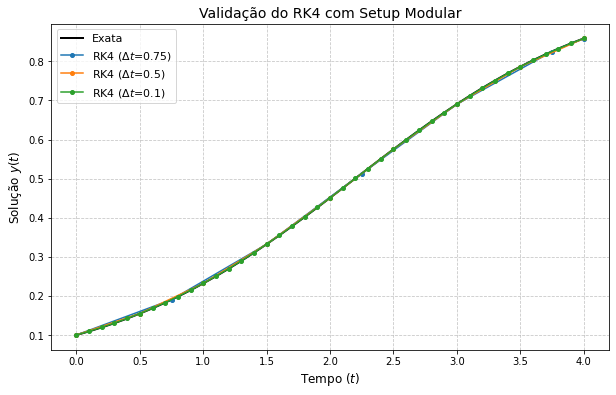

In [8]:
# ====================================================================
# LOOP DE SIMULAÇÃO 
# ====================================================================
t_inicial = 0.0
t_final = 4.0
passos_dt = [0.75, 0.5, 0.1] 

plt.figure(figsize=(10, 6))

# Trocando a física com uma única linha!
# U0_base, Lh, sol_exata = setup_exponencial()
U0_base, Lh, sol_exata = setup_logistico()
# U0_base, Lh, sol_exata = setup_sistema_edo()

# Plot da solução analítica (Curva preta)
t_plot = np.linspace(t_inicial, t_final, 100)
plt.plot(t_plot, sol_exata(t_plot), 'k-', linewidth=2, label='Exata')

for dt_teste in passos_dt:
    U = [u.copy() for u in U0_base]
    t = t_inicial
    dt = dt_teste
    
    historico_t = [t]
    historico_y = [U[0][0]]
    
    while t < t_final:
        if t + dt > t_final:
            dt = t_final - t
            
        # O Motor da simulação agora chama o RK4
        U = RK4_Step(U, t, dt, Lh)
        t += dt
        
        historico_t.append(t)
        historico_y.append(U[0][0])
        
    plt.plot(historico_t, historico_y, marker='o', markersize=4, label=f'RK4 ($\Delta t$={dt_teste})')

plt.title('Validação do RK4 com Setup Modular', fontsize=14)
plt.xlabel('Tempo ($t$)', fontsize=12)
plt.ylabel('Solução $y(t)$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.show()

## **Métodos RKTVD / RKSSP**

> **Referência:** *Strong Stability Preserving Runge-Kutta and Multistep Time Discretizations* (Gottlieb, Ketchenson & Shu)

### **Propriedade TVD (Total Variation Diminishing)**

Em uma dimensão, a lei de conservação hiperbólica é dada por:
$$u_t + f(u)_x = 0$$

Queremos encontar uma aproximação numérica, que discretiza a derivada espacial dessa PDE. O resultado é então um esquema semi-discreto, isto é, uma EDO na variável temporal $t$:
$$u_t = F(u)$$

Normalmente, existe um pequeno parâmetro $\Delta x$ na discretização espacial, por exemplo, o tamanho da malha em um esquema de diferenças finitas, volumes finitos ou elementos finitos de Galerkin descontínuos, que tende a zero com o aumento do desejo de precisão. Normalmente, teríamos:

$$F(u) = -f(u)_x + \mathcal{O}(\Delta x^k)$$

A estabilidade é considerada quando o tamanho do sistema cresce ilimitadamente à medida que o tamanho da malha de discretização espacial $\Delta x$ diminui. Mais importante ainda, existem certas propriedades de estabilidade da EDP original - como a **estabilidade em variação total** ou a **estabilidade na norma do máximo** - que podem ser preservadas pelo esquema semidiscreto. Frequentemente, tais propriedades de estabilidade também são preservadas pelo esquema totalmente discreto

$$u^{n+1} = u^n + \Delta t F(u^n)$$

que é a aproximação de Euler *forward* de primeira ordem. 

Podemos descrever a propriedade principal das discretizações temporais SSP da seguinte forma: se supusermos que a discretização temporal de Euler *foward* de primeira ordem de um esquema semidiscreto do método das linhas é estável segundo uma determinada norma

$$||u^{n+1}|| \leq ||u^n||$$

então, uma discretização temporal de alta ordem do tipo SSP mantém essa estabilidade sob uma restrição adequada ao passo de tempo.

**Resumindo** 

A ideia por trás dos métodos de preservação de estabilidade forte é começar com uma semidiscretização por método de linhas que seja fortemente estável em uma determinada norma, seminorma ou funcional convexo sob o método de Euler *foward* com passo de tempo, quando o passo de tempo $\Delta t$ é adequadamente restrito, e então tentar encontrar uma discretização temporal de ordem superior que mantenha a estabilidade forte para a mesma norma, talvez sob uma restrição de passo de tempo diferente. 

Em outras palavras, dada uma semidiscretização da forma $u_t = F(u)$ e um funcional convexo $|| \cdot ||$, assumimos que existe um valor $\Delta t_{FE}$ tal que

$$||u + \Delta t F(u)|| \leq ||u|| \ \text{para} \ 0 \leq \Delta t \leq \Delta t_{FE}, \forall \ u$$

nós dizemos que o método é *strong stability preserving* (SSP) com o coeficiente $C$ se sempre que a relação anterior for verificada e o passo de tempo satisfaz:
$$\boxed{\Delta t \leq C \Delta t_{FE}}$$

### **Métodos SSP como combinações convexas do Método de Euler - Formulação de Shu-Osher**

Um método explicíto de Runge-Kutta é comulmente escrito no formato de Butcher:

$$
\begin{align*}
u^{(i)} = & u^n + \Delta t \sum_{j=1}^m a_{ij} F(u^{(j)}) \quad (1 \leq i \leq m)\\
u^{n+1} = & u^n + \Delta t \sum_{j=1}^m b_j F(u^{(j)}) 
\end{align*}
$$

e pode ser reescrito também na chamada forma de Shu-Osher

$$\begin{align*} 
u^{(0)} &= u^n \\ 
u^{(i)} &= \sum_{j=0}^{i-1} \left( \alpha_{ij} u^{(j)} + \Delta t \beta_{ij} L(u^{(j)}) \right), \quad 1 \le i \le m \\ 
u^{n+1} &= u^{(m)} 
\end{align*}$$

Para garantir a consistência do método a soma dos coeficientes de combinação deve ser igual a 1:

$$\sum_{j=0}^{i-1} \alpha_{ij} = 1$$

e deve atender o seguinte teorema:

> **Teorema:** Se o método de Euler *foward* é aplicado em $u_t = F(u)$ e é fortemente estável sobre a restrição de passo no tempo $\Delta t \leq \Delta t_{FE}$, e se $\alpha_{ij}, \beta_{ij} \geq 0$, então a solução obtida via Runge-Kutta satisfaz o contorno fortemente estável 
> $$ ||u^{n+1}|| \leq ||u^n|| $$
> sobre a restrição de passo temporal
> $$\Delta t \leq C(\alpha, \beta) \Delta t_{FE}$$
> em que $C(\alpha, \beta) = \min_{i,j} \dfrac{\alpha_{ij}}{\beta_{ij}}$, e a razão é infinita caso $\beta_{ij} = 0$.

---

> **Nota sobre o RK4 Clássico:**  
> Embora o método de Runge-Kutta de 4ª ordem tradicional (RK4) seja amplamente utilizado na resolução de EDOs, ele não satisfaz as condições do teorema acima. Ao tentar expandir o RK4 clássico na formulação de Shu-Osher, inevitavelmente surgem coeficientes negativos ($\alpha_{ij} < 0$ ou $\beta_{ij} < 0$). Isso destrói a natureza de combinação convexa exigida pelo método. Como consequência, o seu coeficiente de preservação de estabilidade forte é nulo ($C = 0$). Por não respeitar a restrição matemática do teorema, o RK4 clássico perde a garantia de estabilidade TVD e gera oscilações espúrias na presença de descontinuidades, exigindo a adoção de métodos com coeficientes SSP otimizados (como os esquemas **SSP de 2ª e 3ª ordem**).

---

### **O Método RKSSP(2,2)**

Na **aula 00** foi comentado que existem formas de integração distintas da família RKSSP, uma delas e que foi mostrada de forma breve é a de **2ª ordem** com **2 estágios**:

$$\begin{align*}
\{c_{i}\}^{*}=& \ \{c_{i}\}^{(t)}+\Delta t\partial_{t}\{c_{i}\}^{(t)} \\
\{c_{i}\}^{(t+\Delta t)}=& \ \frac{1}{2}\{c_{i}\}^{(t)}+ \frac{1}{2} \{c_{i}\}^{*}+ \frac{1}{2} \Delta t\partial_{t}(\{c_{i}\}^{*})
\end{align*}
$$

No entanto, o que não foi salientado naquele contexto, é que está é uma estrutura ótima para esse método, ou seja, esse formato é obtido com o $C$ ótimo, que para este caso é $C = 1$. Se diferentes valores de $C$ fossem adotados teríamos outras estruturas, por exemplo, ao assumir $C = 0$ caíriamos exatamente no método de RK tradicional que advém da regra do trapézio:

$$
\begin{align*}
u^{0} = & u^n\\
u^{1} = & u^{(0)} + \Delta t F(u^{(0)}) \\
u^{n+1} = & u^{(0)} + \dfrac{1}{2} \Delta t F(u^{(0)}) + \dfrac{1}{2}\Delta t F(u^{(1)})
\end{align*}
$$

e para um caso de $C = 1/2$ o termo $u^{n+1}$ teria o formato:
$$u^{n+1} = \dfrac{3}{4}u^{(0)} + \dfrac{1}{4} \Delta t F(u^{(0)}) + \dfrac{1}{4}u^{(1)} + \dfrac{1}{2}\Delta t F(u^{(1)}) $$

Vamos construir a estrutura padrão para o método RK2 com 2 estágios! 

---

#### **Dedução do Método**

Para deduzirmos tal esquema, vamos primeiro recuperar a forma de Shu-Osher

$$\begin{align*} 
u^{(0)} &= u^n \\ 
u^{(i)} &= \sum_{j=0}^{i-1} \left( \alpha_{ij} u^{(j)} + \Delta t \beta_{ij} L(u^{(j)}) \right), \quad 1 \le i \le m \\ 
u^{n+1} &= u^{(m)} 
\end{align*}$$

Então para 2 estágios temos que $m=2$, a expresão anterior quando expandida fica: 

$$\begin{align*} 
u^{(0)} & = u^n \\
u^{(1)} & = \alpha_{10} u^{(0)} + \Delta t \beta_{10} L(u^{(0)}) \\ 
u^{(2)} & = \alpha_{20} u^{(0)} + \alpha_{21} u^{(1)} + \Delta t \beta_{20} L(u^{(0)}) + \Delta t \beta_{21} L(u^{(1)}) \\
u^{n+1} & = u^{(2)}
\end{align*}$$

Da regra de consistência, sabemos imediatamente que $\alpha_{10} = 1$ e $\alpha_{20} + \alpha_{21} = 1$, o que nos dá $\alpha_{20} = 1 - \alpha_{21}$.

**Condição de Ordem (Encontro com a Série de Taylor):**

Para que o método seja verdadeiramente de 2ª Ordem, a sua expansão algébrica deve casar perfeitamente com os coeficientes da Série de Taylor exata até o termo $\Delta t^2$. 

Seja a EDO: 
$$\dfrac{du}{dt} = L(u)$$

A expansão de Taylor exata de $t^n$ para $t^{n+1} = t^n + \Delta t$:
$$u(t^{n+1}) = u(t^n) + \Delta t \dfrac{du}{dt}(t^n) + \dfrac{\Delta t^2}{2} \dfrac{d^2u}{dt^2}(t^n) + \mathcal{O}(t^3)$$

sabemos que $\dfrac{du}{dt} = L(u)$ logo:
$$\dfrac{d^2u}{dt^2} = \dfrac{d}{dt} \Big (\dfrac{du}{dt} \Big) = \dfrac{d}{dt}(L(u)) = \frac{\partial L}{\partial u} \frac{du}{dt} = \frac{\partial L}{\partial u} L(u) =  L_u L(u)$$

chamando $L(u(t^n)) = L^n$ e $L_u(u(t^n)) = L^n_u$

$$u^{n+1} = u^n + \Delta t L^n + \frac{\Delta t^2}{2} L_u^n L^n$$

relembrando nossas equações:
$$\begin{align*} 
u^{(1)} &= u^{(0)} + \Delta t \beta_{10} L(u^{(0)}) \\ 
u^{(2)} &= \alpha_{20} u^{(0)} + \alpha_{21} u^{(1)} + \Delta t \beta_{20} L(u^{(0)}) + \Delta t \beta_{21} L(u^{(1)}) 
\end{align*}$$

como $n$ é o tempo conhecido na expansão de Taylor, ele é equivalente ao $(0)$ das nossas equações, além disso como escolhemos **2 estágios** o $ u^{(2)} = u^{(n+1)} $, portanto:
$$
\boxed{
\begin{align*} 
u^{(1)} &= u^{(n)} + \Delta t \beta_{10} L(u^{(n)}) \\ 
u^{(n+1)} &= \alpha_{20} u^{(n)} + \alpha_{21} u^{(1)} + \Delta t \beta_{20} L(u^{(n)}) + \Delta t \beta_{21} L(u^{(1)}) 
\end{align*}}
$$

> Todo método de Runge-Kutta explicíto de 2ª Ordem com 2 Estágios podem ser escritos nesse formato! Ao qual nos referimos por **SSPRK**$\mathbf{(2,2)}$

---

#### **Problema de Otimização**

Vamos continuar o nosso processo de resolução para encontrar o melhor valor de $C$. Das equações deduzidas temos que:
$$L(u^{(1)}) = L(u^{(n)} + \Delta t \beta_{10} L(u^{(n)})) \approx L^n + \Delta t \beta_{10} L_u^n L^n$$

substituindo:
$$u^{(n+1)} = \alpha_{20} u^{(n)} + \alpha_{21} (u^{(n)} + \Delta t \beta_{10} L^{n}) + \Delta t \beta_{20} L^n + \Delta t \beta_{21} [L^n + \Delta t \beta_{10} L_u^n L^n]$$

agrupando os termos semelhantes e detacando os coeficientes da Série de Taylor:
$$u^{(n+1)} = \underbrace{(\alpha_{20} + \alpha_{21})}_{1} u^n + \Delta t \underbrace{(\alpha_{21}\beta_{10} + \beta_{20} + \beta_{21})}_{1} L^n + \Delta t^2 \underbrace{(\beta_{10}\beta_{21})}_{{1}/{2}} L_u^n L^n$$

Chegamos ao que é conhecido como **Condições de Ordem**:  
$$\alpha_{20} + \alpha_{21} = 1 \hspace{2cm} \alpha_{21} \beta_{10} + \beta_{20} + \beta_{21} = 1 \hspace{2cm} \beta_{21} \beta_{10} = \frac{1}{2}$$

Vamos tomar como índice livre $\beta_{10}$ e $\alpha_{21}$
$$
\begin{align*}
\alpha_{20} = & \ 1 - \alpha_{21} \\
\beta_{20} = & \ 1 - \dfrac{1}{2 \beta_{10}} - \alpha_{21} \beta_{10} \\
\beta_{21} = & \ \dfrac{1}{2 \beta_{10}} 
\end{align*}
$$

Temos um sistema com 3 equações e 5 variáveis ($\alpha_{20}, \alpha_{21}, \beta_{10}, \beta_{20}, \beta_{21}$). 

> **Nota:** O valor de $\alpha_{10} = 1$ conhecido de antemão irá nos ajudar no processo de otimização! Sendo ela a nossa **quarta equação**.

Como queremos a maior estabilidade possível, formulamos um **problema de otimização** para encontrar o maior passo de tempo permitido. Tal estabilidade é garantida caso
$$ \Delta t \leq C \Delta t_{FE}$$

e o parâmetro $C$ é definido como:

$$C = \min_{i,j} \frac{\alpha_{ij}}{\beta_{ij}}$$

com $\alpha_{ij}, \beta_{ij} \geq 0$ conforme o Teorema apresentado anteriormente, a definição de $C$ nos dá a **quinta equação** para acharmos os demais coeficientes. 

A literatura nos diz que $C=1$ é o ótimo para esse problema! Podemos averiguar isso fazendo uma demonstração por contradição. 

---
**Demonstração**  
Vamos tomar $C > 1$ para isso acontecer teríamos:
$$
\frac{\alpha_{10}}{\beta_{10}} = \frac{1}{\beta_{10}} > 1 \Rightarrow \beta_{10} < 1
$$
o que também implicaria em:
$$2 \beta_{10} < 2 \Rightarrow \dfrac{1}{2\beta_{10}} > \dfrac{1}{2} $$

como as razões entre os coeficientes devem ser sempre satisfeitas, então
$$\frac{\alpha_{21}}{\beta_{21}} > 1 \Rightarrow \alpha_{21} > \beta_{21} = \dfrac{1}{2\beta_{10}}$$

isso implica diretamente que $\alpha_{21}\beta_{10} > \dfrac{1}{2} $. 

Agora vamos montar a equação de $\beta_{20}$, o que segue:
$$\dfrac{1}{2\beta_{10}} > \dfrac{1}{2} \Rightarrow - \dfrac{1}{2\beta_{10}} < -\dfrac{1}{2}$$
subtraindo por $\alpha_{21}\beta_{10}$
$$- \dfrac{1}{2\beta_{10}} - \alpha_{21}\beta_{10} < -\dfrac{1}{2} - \alpha_{21}\beta_{10} < -\dfrac{1}{2} -\dfrac{1}{2}$$
somando 1 
$$\beta_{20} = 1 - \dfrac{1}{2\beta_{10}} - \alpha_{21}\beta_{10} < 1 - \dfrac{1}{2}  -  \dfrac{1}{2} = 0$$
ou seja chegamos que 
$$\beta_{20} \leq 0 $$
o que contradiz o Teorema! 

---

Sendo $C = 1$ então os coeficientes ótimos serão: 

* $\alpha_{10} = 1$ e $\beta_{10} = 1$
* $\alpha_{21} = \dfrac{1}{2}$ e $\beta_{21} = \dfrac{1}{2}$
* $\alpha_{20} = \dfrac{1}{2}$ e $\beta_{20} = 0$ 

Substituindo esses coeficientes de volta nas nossas equações, revelamos o formato **ótimo** para o método **SSPRK**$\mathbf{(2,2)}$:  

$$
\boxed{
\begin{align*} 
u^{(1)} &= u^n + \Delta t L(u^n) \\ 
u^{n+1} &= \frac{1}{2} u^n + \frac{1}{2} u^{(1)} + \frac{1}{2} \Delta t L(u^{(1)}) 
\end{align*}
}
$$
que é exatamente o mesmo formato ao apresentado na **Aula 00**.

Note a beleza dessa formulação: 
* o primeiro estágio ($u^{(1)}$) é puramente um passo de Euler Explícito; 
* o segundo estágio é a média (combinação convexa) entre o estado inicial $u^n$ e um novo passo de Euler dado a partir de $u^{(1)}$; 

Sendo médias de passos de Euler, a propriedade TVD está garantida!

### **Métodos de Terceira Ordem**

Os métodos de terceira ordem, devido sua estrutura, permite com que quantidades de estágios diferentes sejam definidas. As duas configurações mais comuns para a terceira ordem são os métodos **SSPRK(3,3)** (3 estágios) e o **SSPRK(5,3)** (5 estágios).

No caso do **SSPRK(3,3)** o valor de $C$ que otimiza a estrutura do método é $C = 1$ e ele é escrito da forma:

$$
\boxed{
\begin{align*} 
u^{(1)} &= u^n + \Delta t L(u^n) \\ 
u^{(2)} &= \frac{3}{4} u^n + \frac{1}{4} u^{(1)} + \frac{1}{4} \Delta t L(u^{(1)}) \\
u^{n+1} &= \frac{1}{3} u^n + \frac{2}{3} u^{(2)} + \frac{2}{3} \Delta t L(u^{(2)})
\end{align*}
}
$$

Embora ambos os métodos **SSPRK(2,2)** e **SSPRK(3,3)** possuam um coeficiente SSP $C = 1$ - o que permite um passo de tempo de mesma magnitude que o método de Euler *foward* -, é evidente que o custo computacional é o dobro e o triplo (respectivamente) do custo do método de Euler *foward*. Assim, é útil definir o **coeficiente SSP efetivo** como

$$C_{eff} = \dfrac{C}{m}$$

em que $m$ é, tipicamente, igual ao número de estágios.

Nesse sentido, os casos **SSPRK(2,2)** e **SSPRK(3,3)** tem coeficiente efetivos $C_{eff} = \dfrac{1}{2}$ e $C_{eff} = \dfrac{1}{3}$, respectivamente.

Para uma dada ordem de precisão, se permitirmos mais estágios, podemos obter um coeficiente SSP maior. Mais importante ainda, métodos SSPRK ótimos com mais estágios tipicamente apresentam um coeficiente SSP efetivo maior. Por exemplo, o método ótimo de cinco estágios e terceira ordem SSPRK(5,3)

$$
\begin{align*}
u^{(1)} &= u^n + 0.37726891511710\,\Delta t\,F(u^n), \\[0.5em]

u^{(2)} &= u^{(1)} + 0.37726891511710\,\Delta t\,F(u^{(1)}), \\[0.5em]

u^{(3)} &= 0.56656131914033\,u^n
+ 0.43343868085967\,u^{(2)} \\
&\quad + 0.163552294089771\,\Delta t\,F(u^{(2)}), \\[0.5em]

u^{(4)} &= 0.09299483444413\,u^n
+ 0.00002090369620\,u^{(1)} \\
&\quad + 0.90698426185967\,u^{(3)}
+ 0.00071997378654\,\Delta t\,F(u^n) \\
&\quad + 0.34217696850008\,\Delta t\,F(u^{(3)}), \\[0.5em]

u^{(5)} &= 0.00736132260920\,u^n
+ 0.20127980325145\,u^{(1)} \\
&\quad + 0.00182955389682\,u^{(2)}
+ 0.78952932024253\,u^{(4)} \\
&\quad + 0.00277719819460\,\Delta t\,F(u^n)
+ 0.00001567934613\,\Delta t\,F(u^{(1)}) \\
&\quad + 0.29786487010104\,\Delta t\,F(u^{(4)}).
\end{align*}
$$

tem $C_{eff} \approx 0.53$, que é maior do que o do SSPRK(3,3).

### **Métodos de Quarta Ordem**

Para utilização no Método DG, onde o custo de avaliar o operador espacial $L_h$ (Matrizes de Massa, Rigidez e Fluxos Numéricos) é alto, precisamos de métodos de integração no tempo que ofereçam altíssima precisão (4ª Ordem) aliados à maior região de estabilidade possível (maior passo de tempo $\Delta t$ sem destruir a propriedade TVD).

Nesse cenário, destacam-se os esquemas de múltiplos estágios SSPRK(5,4) e SSPRK(10,4). O trade-off é claro: nós calculamos mais estágios intermediários do que a ordem teórica do método exige, mas o ganho na estabilidade permite passos de tempo muito maiores, barateando o custo global da simulação.

#### **SSPRK(5,4)**

Esse método tem coeficiente SSP $C = 1.508$, e coeficiente efetivo $C_{eff} = 0.302$, o que significa que ele é um método maior ordem e ligeiramente menos eficiente do que o SSPRK(3,3)

$$
\begin{align*}
u^{(1)} &= u^n + 0.391752226571890 \Delta t F(u^n) \\
u^{(2)} &= 0.444370493651235 u^n + 0.555629506348765 u^{(1)} \\
&\quad + 0.368410593050371 \Delta t F(u^{(1)}) \\
u^{(3)} &= 0.620101851488403 u^n + 0.379898148511597 u^{(2)} \\
&\quad + 0.251891774271694 \Delta t F(u^{(2)}) \\
u^{(4)} &= 0.178079954393132 u^n + 0.821920045606868 u^{(3)} \\
&\quad 0.544974750228521 \Delta t F(u^{(3)}) \\
u^{n+1} &= 0.517231671970585 u^{(2)} \\
&\quad + 0.096059710526147 u^{(3)} + 0.063692468666290 \Delta t F(u^{(3)}) \\
&\quad + 0.386708617503269 u^{(4)} + 0.226007483236906 \Delta t F(u^{(4)}).
\end{align*}
$$

Como em métodos numéricos, sempre se buscam melhorias nas técnicas este esquema foi otimizado por **Spiteri e Ruuth**. Os autores no entanto, partiram do formalismo da estrutura de Butcher, isto é:

$$
\begin{align*}
u^{(i)} = & u^n + \Delta t \sum_{j=1}^m a_{ij} F(u^{(j)}) \quad (1 \leq i \leq m)\\
u^{n+1} = & u^n + \Delta t \sum_{j=1}^m b_j F(u^{(j)}) 
\end{align*}
$$

Neste formalismo a avaliação da função em cada estágio, receberá o resultado do estágio anterior e haverá ponderações no passo temporal, isso se expressa da seguinte forma:

$$\begin{align*} 
u^{(1)} &= u^n + 0.39175222700392 \Delta t L_h(u^n, t^n) \\ \\
u^{(2)} &= 0.44437049406734 u^n + 0.55562950593266 u^{(1)}  \\
        &\quad + 0.36841059262959 \Delta t L_h(u^{(1)}, t^n + 0.39175222700392 \Delta t) \\ \\
u^{(3)} &= 0.62010185138540 u^n + 0.37989814861460 u^{(2)} \\ 
        &\quad + 0.25189177424738 \Delta t L_h(u^{(2)}, t^n + 0.58607968896780 \Delta t) \\ \\
u^{(4)} &= 0.17807995410773 u^n + 0.82192004589227 u^{(3)} \\
        &\quad + 0.54497475021237 \Delta t L_h(u^{(3)}, t^n + 0.47454236302687 \Delta t) \\ \\
u^{n+1} &= 0.00683325884039 u^n + 0.51723167208978 u^{(2)} \\
        &\quad + 0.12759831133288 u^{(3)}  + 0.34833675773694 u^{(4)} \\
        &\quad + 0.08460416338212 \Delta t L_h(u^{(3)}, t^n + 0.47454236302687 \Delta t) \\
        &\quad + 0.22600748319395 \Delta t L_h(u^{(4)}, t^n + 0.93501063100924 \Delta t) \end{align*}$$

---


### **Codando o RKSSP54**

In [9]:
import numpy as np
from typing import Callable, List, Optional

def RKSSP54_Step(
    U_modal: List[np.ndarray], 
    t: float, 
    dt: float, 
    Lh_operator: Callable, 
    limiter_func: Optional[Callable] = None
) -> List[np.ndarray]:
    """ Integrador RK SSP 5 Estágios / 4ª Ordem (Spiteri-Ruuth) """
    num_vars = len(U_modal)
    
    def apply_limiter(U_state):
        if limiter_func is not None:
            return [limiter_func(u) for u in U_state]
        return U_state

    # Estágio 1
    k1 = Lh_operator(U_modal, t)
    U1 = [U_modal[i] + 0.39175222700392 * dt * k1[i] for i in range(num_vars)]
    U1 = apply_limiter(U1)
    
    # Estágio 2
    k2 = Lh_operator(U1, t + 0.39175222700392 * dt)
    U2 = [0.44437049406734 * U_modal[i] + 0.55562950593266 * U1[i] + 0.36841059262959 * dt * k2[i] for i in range(num_vars)]
    U2 = apply_limiter(U2)
    
    # Estágio 3
    k3 = Lh_operator(U2, t + 0.58607968896780 * dt)
    U3 = [0.62010185138540 * U_modal[i] + 0.37989814861460 * U2[i] + 0.25189177424738 * dt * k3[i] for i in range(num_vars)]
    U3 = apply_limiter(U3)
    
    # Estágio 4
    k4 = Lh_operator(U3, t + 0.47454236302687 * dt)
    U4 = [0.17807995410773 * U_modal[i] + 0.82192004589227 * U3[i] + 0.54497475021237 * dt * k4[i] for i in range(num_vars)]
    U4 = apply_limiter(U4)
    
    # Estágio 5 (Passo Final)
    k5 = Lh_operator(U4, t + 0.93501063100924 * dt)
    U_new = [
        0.00683325884039 * U_modal[i] + 
        0.51723167208978 * U2[i] + 
        0.12759831133288 * U3[i] + 
        0.34833675773694 * U4[i] + 
        0.08460416338212 * dt * k4[i] + 
        0.22600748319395 * dt * k5[i] 
        for i in range(num_vars)
    ]
    U_new = apply_limiter(U_new)
    
    return U_new

#### **SSPRK(10,4)**

Para simulações extremamente agressivas, este método possui um coeficiente SSP $C = 6$. Ele é provado matematicamente como o esquema ótimo entre todos os métodos de 4ª ordem com dez estágios. O custo assustador de avaliar o operador 10 vezes por passo de tempo é compensado pelo coeficiente SSP colossal, que permite avanços rápidos na simulação. A sua estrutura possui estágios repetitivos elegantes:

$$
\begin{align*}
u^{(1)} &= u^n + \dfrac{1}{6} \Delta t F(u^{n}) \\
u^{(2)} &= u^{(1)} + \dfrac{1}{6} \Delta t F(u^{(1)}) \\
u^{(3)} &= u^{(2)} + \dfrac{1}{6} \Delta t F(u^{(2)}) \\
u^{(4)} &= u^{(3)} + \dfrac{1}{6} \Delta t F(u^{(3)}) \\
u^{(5)} &= \dfrac{3}{5} u^n + \dfrac{2}{5} u^{(4)} + \dfrac{1}{15} \Delta t F(u^{(4)}) \\
u^{(6)} &= u^{(5)} + \dfrac{1}{6} \Delta t F(u^{(5)}) \\
u^{(7)} &= u^{(6)} + \dfrac{1}{6} \Delta t F(u^{(6)}) \\
u^{(8)} &= u^{(7)} + \dfrac{1}{6} \Delta t F(u^{(7)}) \\
u^{(9)} &= u^{(8)} + \dfrac{1}{6} \Delta t F(u^{(8)}) \\
u^{n+1} &= \dfrac{1}{25}u^n + \dfrac{9}{25}u^{(4)} + \dfrac{3}{5}u^{(9)} + \dfrac{3}{50}\Delta t F(u^{(4)}) + \dfrac{1}{10}\Delta t F(u^{(9)}) 
\end{align*}
$$


> **Nota de Implementação (O Vetor de Tempo)**  
> Em problemas clássicos de CFD, como a Equação de Burgers Invíscida ou as Equações de Euler, o operador espacial $L_h$ costuma ser autônomo (a física do escoamento não possui forças externas que variam explicitamente com o tempo $t$). Nesses casos específicos, avaliar $L_h(u, t^n)$ ou $L_h(u, t^n + c_i \Delta t)$ produz exatamente o mesmo resultado numérico.  
> Por praticidade e economia computacional, muitas implementações (como a que utilizaremos para o SSPRK104) repassam apenas o tempo global $t^n$ para todos os estágios intermediários. No entanto, é fundamental estar ciente de que, se o solver for utilizado para problemas não-autônomos (como osciladores forçados ou fronteiras móveis no tempo), os incrementos de tempo estritos do Tableau de Butcher ($c_i \Delta t$) devem ser obrigatoriamente calculados e repassados ao operador para que a 4ª ordem de precisão não seja destruída.

### **Codando o SSPRK104**

In [10]:
def RKSSP104_Step(
    U_modal: List[np.ndarray], 
    t: float, 
    dt: float, 
    Lh_operator: Callable, 
    limiter_func: Optional[Callable] = None
) -> List[np.ndarray]:
    """ Integrador RK SSP 10 Estágios / 4ª Ordem """
    num_vars = len(U_modal)
    
    def apply_limiter(U_state):
        if limiter_func is not None:
            return [limiter_func(u) for u in U_state]
        return U_state

    U_curr = [u.copy() for u in U_modal]
    
    # Estágios de 1 a 4 (Padrão repetitivo)
    for _ in range(4):
        k = Lh_operator(U_curr, t)
        U_curr = [U_curr[i] + (dt / 6.0) * k[i] for i in range(num_vars)]
        U_curr = apply_limiter(U_curr)
        
    # Salvamos o U4 e k5 para o Passo 10 e Passo 5
    U4 = [u.copy() for u in U_curr]
    k5 = Lh_operator(U4, t)
    
    # Estágio 5
    U_curr = [
        (3.0 / 5.0) * U_modal[i] + (2.0 / 5.0) * U4[i] + (1.0 / 15.0) * dt * k5[i]
        for i in range(num_vars)
    ]
    U_curr = apply_limiter(U_curr)
    
    # Estágios 6 a 9 (Novo padrão repetitivo)
    for _ in range(4):
        k = Lh_operator(U_curr, t)
        U_curr = [U_curr[i] + (dt / 6.0) * k[i] for i in range(num_vars)]
        U_curr = apply_limiter(U_curr)
        
    # U_curr neste momento é o U9
    U9 = U_curr
    k10 = Lh_operator(U9, t)
    
    # Estágio 10 (Passo Final)
    U_new = [
        (1.0 / 25.0) * U_modal[i] + 
        (9.0 / 25.0) * U4[i] + 
        (3.0 / 5.0) * U9[i] + 
        (3.0 / 50.0) * dt * k5[i] + 
        (1.0 / 10.0) * dt * k10[i]
        for i in range(num_vars)
    ]
    U_new = apply_limiter(U_new)
    
    return U_new

### **Testando nossos códigos**

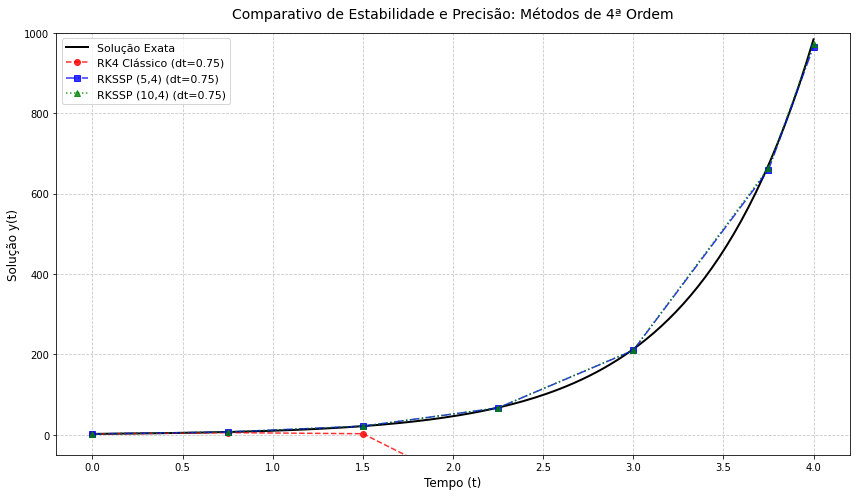

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ====================================================================
# COMPARATIVO DE INTEGRADORES DE 4ª ORDEM
# ====================================================================
t_inicial = 0.0
t_final = 4.0

# Escolhemos um passo de tempo que sabemos ser "perigoso" para testar a estabilidade
dt_teste = 0.75 

plt.figure(figsize=(12, 7))

# 1. Carrega a física do problema e plota a solução analítica
# U0_base, Lh, sol_exata = setup_exponencial()
# U0_base, Lh, sol_exata = setup_logistico()
U0_base, Lh, sol_exata = setup_sistema_edo()

t_plot = np.linspace(t_inicial, t_final, 200)
plt.plot(t_plot, sol_exata(t_plot), 'k-', linewidth=2, label='Solução Exata')

# 2. Catálogo de Integradores para o loop
integradores = {
    'RK4 Clássico': RK4_Step,
    'RKSSP (5,4)': RKSSP54_Step,
    'RKSSP (10,4)': RKSSP104_Step
}

# Dicionário de estilos para diferenciar bem as curvas no gráfico
estilos = {
    'RK4 Clássico': {'marker': 'o', 'color': 'red', 'linestyle': '--'},
    'RKSSP (5,4)': {'marker': 's', 'color': 'blue', 'linestyle': '-.'},
    'RKSSP (10,4)': {'marker': '^', 'color': 'green', 'linestyle': ':'}
}

# 3. Executa a simulação iterando sobre cada integrador
for nome, integrador in integradores.items():
    
    # Restaura a condição inicial limpa para o integrador atual
    U = [u.copy() for u in U0_base]
    t = t_inicial
    dt = dt_teste
    
    historico_t = [t]
    historico_y = [U[0][0]] # Guardamos a posição y
    
    # Marcha no tempo
    while t < t_final:
        if t + dt > t_final:
            dt = t_final - t
            
        # A MÁGICA DA MODULARIDADE: Chama a função do integrador dinamicamente
        U = integrador(U, t, dt, Lh)
        t += dt
        
        historico_t.append(t)
        historico_y.append(U[0][0])
        
    # Plota a curva do método atual
    plt.plot(historico_t, historico_y, 
             label=f'{nome} (dt={dt_teste})',
             marker=estilos[nome]['marker'],
             color=estilos[nome]['color'],
             linestyle=estilos[nome]['linestyle'],
             markersize=6, alpha=0.8)

# ====================================================================
# ESTÉTICA DO GRÁFICO
# ====================================================================
plt.title('Comparativo de Estabilidade e Precisão: Métodos de 4ª Ordem', fontsize=14, pad=15)
plt.xlabel('Tempo (t)', fontsize=12)
plt.ylabel('Solução y(t)', fontsize=12)
# Limitamos o eixo Y para não deixar o provável blow-up do RK4 esmagar as outras curvas
plt.ylim(-50, 1000) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

## **Problemas com expressões temporais**

Se você acompanhou a implementação do SSPRK(10,4) e testou no sistema de EDOs anterior (que continha um $\sin(t)$ no termo fonte), pode ter notado que o gráfico gerado pareceu perfeitamente correto e estável.

Isso levanta uma dúvida natural: Se nós não atualizamos as frações de tempo no interior dos 10 estágios do método (ignorando a correção $t + c_i \Delta t$ ditada pela teoria de Butcher), por que o método não explodiu?

A resposta é que fomos vítimas de uma ilusão visual. Naquele sistema, a parte autônoma das equações (que não depende de $t$) ditava um crescimento exponencial forte que dominou completamente a escala do eixo Y. O erro gerado pela avaliação defasada do $\sin(t)$ ficou mascarado nas pequenas casas decimais e não pôde ser visto a olho nu.

No entanto, em Computação Científica de alto desempenho, nós não validamos códigos com o "olhômetro" dos gráficos. Nós utilizamos a Análise de Convergência. A teoria garante que, para um método ser de 4ª Ordem, ao cortarmos o tamanho do passo no tempo ($\Delta t$) pela metade, o erro global da solução deve cair $2^4 = 16$ vezes. Se a taxa de queda do erro for inferior a isso, significa que o nosso método perdeu a sua ordem original de precisão ($p$).

Para forçar a máscara a cair e expormos o perigo de congelar o tempo $t$ nos estágios intermediários, precisamos de um problema teste não-autônomo onde a variação temporal seja a protagonista absoluta do fenômeno.

#### **Exemplo com Problema Não-autônomo**

Considere o seguinte Problema de Valor Inicial:
$$\frac{dy}{dt} = y \cos(t) \hspace{2cm} y(0) = 1$$

A solução exata analítica desta EDO é dada por:

$$y_{exato}(t) = e^{\sin(t)}$$

Na sequência, vamos submeter os nossos dois integradores - o RK4 Clássico (que possui as atualizações rigorosas de tempo da forma $t + 0.5\Delta t$ e $t + \Delta t$ embutidas no código) e o nosso recém-criado SSPRK(10,4) (que avalia todos os estágios usando o mesmo $t$ fixo) - a um teste de redução sucessiva de malha temporal para avaliarmos a ordem de convergência ($p$) de cada um.


#### **Como calculamos a Ordem de Convergência ($p$)?**

Para medir a ordem de convergência ($p$) na prática, observamos como o erro numérico absoluto ($E$) se comporta ao reduzirmos o passo de tempo ($\Delta t$). Teoricamente, o erro de um método numérico é proporcional ao passo elevado à sua ordem matemática: $E \approx C(\Delta t)^p$.

Se simularmos o mesmo problema duas vezes, cortando o passo de tempo pela metade na segunda rodada ($\Delta t_{novo} = \frac{\Delta t_{velho}}{2}$), podemos isolar a ordem $p$ aplicando o logaritmo na razão dos erros. Como a razão de redução do passo é exatamente 2, a fórmula se simplifica de forma direta para:

$$p = \log_2 \left( \frac{E_{velho}}{E_{novo}} \right)$$

Essa é a conta exata que faremos no código a seguir. Se o método estiver operando em sua verdadeira 4ª Ordem, a nossa conta deverá retornar $p \approx 4$ (mostrando que o erro caiu $2^4 = 16$ vezes). Se o cálculo retornar $p \approx 1$, saberemos que o método regrediu criticamente para a 1ª Ordem (o erro caiu apenas 2 vezes).


=== Testando: RK4 Clássico (Com correção) ===
dt         | Erro Absoluto   | Ordem (p) 
------------------------------------------
1.00000    | 8.80e-03        | 0.00      
0.50000    | 6.76e-04        | 3.70      
0.25000    | 4.24e-05        | 3.99      
0.12500    | 2.60e-06        | 4.03      
0.06250    | 1.60e-07        | 4.02      
0.03125    | 9.87e-09        | 4.01      

=== Testando: SSPRK(10,4) (Sem correção) ===
dt         | Erro Absoluto   | Ordem (p) 
------------------------------------------
1.00000    | 2.18e+00        | 0.00      
0.50000    | 9.88e-01        | 1.14      
0.25000    | 4.67e-01        | 1.08      
0.12500    | 2.27e-01        | 1.04      
0.06250    | 1.12e-01        | 1.02      
0.03125    | 5.54e-02        | 1.01      


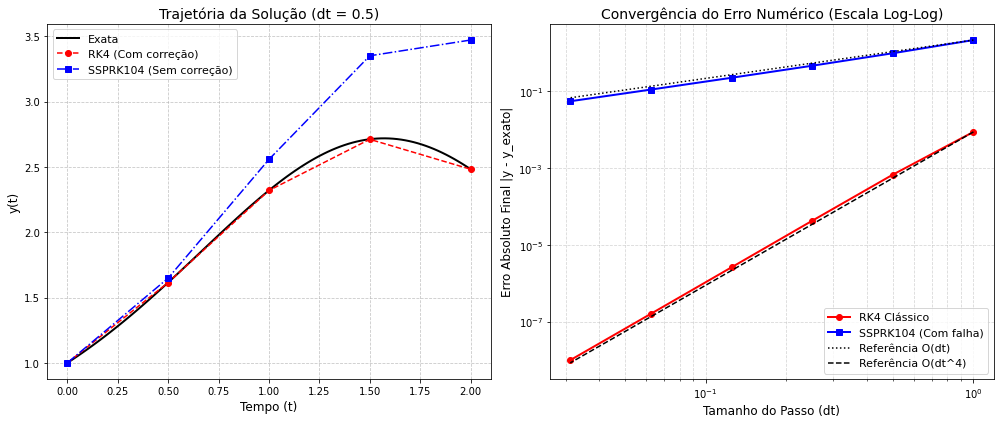

In [35]:
# SETUP DO PROBLEMA (dy/dt = y * cos(t))
def setup_teste_tempo():
    U0 = [np.array([1.0])]
    def Lh(U_modal, t): return [U_modal[0] * np.cos(t)]
    def sol_exata(t): return np.exp(np.sin(t))
    return U0, Lh, sol_exata

# EXTRAÇÃO DE DADOS PARA A TABELA E OS GRÁFICOS
t_inicial = 0.0
t_final = 2.0
passos_dt = [1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125]

U0_base, Lh, sol_exata = setup_teste_tempo()
valor_exato_final = sol_exata(t_final)


################### TABELA DE AVALIACAO DE ERRO #################
integradores = {'RK4 Clássico (Com correção)': RK4_Step, 'SSPRK(10,4) (Sem correção)': RKSSP104_Step}
for nome, integrador in integradores.items():
    print(f"\n=== Testando: {nome} ===")
    print(f"{'dt':<10} | {'Erro Absoluto':<15} | {'Ordem (p)':<10}")
    print("-" * 42)
    
    erro_anterior = None
    
    for dt_teste in passos_dt:
        U = [u.copy() for u in U0_base]
        t = t_inicial
        dt = dt_teste
        
        while t < t_final:
            if t + dt > t_final:
                dt = t_final - t
            U = integrador(U, t, dt, Lh)
            t += dt
            
        erro_atual = abs(U[0][0] - valor_exato_final)
        
        # Calculando a Ordem de Convergência p = log2(Erro_velho / Erro_novo)
        ordem = np.log2(erro_anterior / erro_atual) if erro_anterior is not None else 0.0
        
        print(f"{dt_teste:<10.5f} | {erro_atual:<15.2e} | {ordem:<10.2f}")
        erro_anterior = erro_atual
############################################################################


erros_rk4 = []
erros_ssp = []
# Coletando os erros para o Log-Log
for dt_teste in passos_dt:
    # RK4
    U_rk4 = [u.copy() for u in U0_base]
    t = t_inicial
    dt = dt_teste
    while t < t_final:
        if t + dt > t_final: dt = t_final - t
        U_rk4 = RK4_Step(U_rk4, t, dt, Lh)
        t += dt
    erros_rk4.append(abs(U_rk4[0][0] - valor_exato_final))
    
    # SSP104
    U_ssp = [u.copy() for u in U0_base]
    t = t_inicial
    dt = dt_teste
    while t < t_final:
        if t + dt > t_final: dt = t_final - t
        U_ssp = RKSSP104_Step(U_ssp, t, dt, Lh)
        t += dt
    erros_ssp.append(abs(U_ssp[0][0] - valor_exato_final))

# Coletando trajetórias visuais com dt = 0.5
t_traj = t_inicial
dt_traj = 0.5
U_rk4_traj = [u.copy() for u in U0_base]
U_ssp_traj = [u.copy() for u in U0_base]
hist_t = [t_traj]
hist_rk4 = [U_rk4_traj[0][0]]
hist_ssp = [U_ssp_traj[0][0]]

while t_traj < t_final:
    if t_traj + dt_traj > t_final: dt_traj = t_final - t_traj
    U_rk4_traj = RK4_Step(U_rk4_traj, t_traj, dt_traj, Lh)
    U_ssp_traj = RKSSP104_Step(U_ssp_traj, t_traj, dt_traj, Lh)
    t_traj += dt_traj
    hist_t.append(t_traj)
    hist_rk4.append(U_rk4_traj[0][0])
    hist_ssp.append(U_ssp_traj[0][0])

# ====================================================================
# PLOTAGEM DOS GRÁFICOS
# ====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- GRÁFICO 1: Trajetória Visual ---
t_plot = np.linspace(t_inicial, t_final, 100)
ax1.plot(t_plot, sol_exata(t_plot), 'k-', linewidth=2, label='Exata')
ax1.plot(hist_t, hist_rk4, 'ro--', markersize=6, label='RK4 (Com correção)')
ax1.plot(hist_t, hist_ssp, 'bs-.', markersize=6, label='SSPRK104 (Sem correção)')
ax1.set_title('Trajetória da Solução (dt = 0.5)', fontsize=14)
ax1.set_xlabel('Tempo (t)', fontsize=12)
ax1.set_ylabel('y(t)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(fontsize=11)

# --- GRÁFICO 2: Análise de Convergência (Log-Log) ---
ax2.loglog(passos_dt, erros_rk4, 'ro-', markersize=6, linewidth=2, label='RK4 Clássico')
ax2.loglog(passos_dt, erros_ssp, 'bs-', markersize=6, linewidth=2, label='SSPRK104 (Com falha)')

# Linhas de referência de inclinação (1ª Ordem e 4ª Ordem)
ref_ordem1 = [erros_ssp[0] * (dt / passos_dt[0])**1.0 for dt in passos_dt]
ref_ordem4 = [erros_rk4[0] * (dt / passos_dt[0])**4.0 for dt in passos_dt]
ax2.loglog(passos_dt, ref_ordem1, 'k:', linewidth=1.5, label='Referência O(dt)')
ax2.loglog(passos_dt, ref_ordem4, 'k--', linewidth=1.5, label='Referência O(dt^4)')

ax2.set_title('Convergência do Erro Numérico (Escala Log-Log)', fontsize=14)
ax2.set_xlabel('Tamanho do Passo (dt)', fontsize=12)
ax2.set_ylabel('Erro Absoluto Final |y - y_exato|', fontsize=12)
ax2.grid(True, which="both", linestyle='--', alpha=0.5)
ax2.legend(fontsize=11)

# Ajuste de layout e exibição
plt.tight_layout()
plt.show()

### **Truque Matemático**

O grande insight para contornar a limitação do tempo congelado é simples, porém genial: se o nosso motor de integração é excelente em atualizar o vetor de estados $\mathbf{U}$, nós faremos com que o próprio tempo $t$ deixe de ser um parâmetro externo e passe a ser uma das variáveis físicas dentro de $\mathbf{U}$.

Vamos reaproveitar exatamente o nosso problema anterior:
$$\frac{dy}{dt} = y \cos(t)$$

Em vez de um vetor unidimensional contendo apenas a variável espacial, nós expandimos o espaço de estados para duas dimensões. A nossa primeira variável será o $y$ e a segunda variável será o nosso "tempo interno" ($t_{int}$):

$$\mathbf{U} = \begin{bmatrix} y \\ t_{int} \end{bmatrix}$$

Para o operador espacial $L_h$ funcionar, ele precisa retornar as derivadas de cada elemento do vetor. A derivada de $y$ nós já conhecemos. E qual é a derivada do tempo em relação ao próprio tempo? É simplesmente 1! Logo, o nosso sistema se transforma em um sistema estritamente autônomo acoplado:

$$\frac{d\mathbf{U}}{dt} = \begin{bmatrix} y \cos(t_{int}) \\ 1 \end{bmatrix}$$

Com essa formulação elegante, nós enganamos o integrador temporal. O tempo avança perfeitamente guiado pela própria máquina de combinações convexas do Runge-Kutta, sem precisarmos caçar os coeficientes de tempo de Butcher na literatura.

Na sequência, aplicaremos este novo setup e apresentaremos exatamente as mesmas tabelas e gráficos. Observe como essa simples manipulação de Álgebra Linear restaura a glória do SSPRK(10,4), fazendo a sua curva de erro desabar de volta para a 4ª Ordem Teórica!

In [28]:
# ====================================================================
# SETUP DO PROBLEMA TRANSFORMADO EM AUTÔNOMO (dy/dt = y * cos(t))
# ====================================================================
def setup_teste_tempo_autonomo():
    """ 
    EDO não-autônoma: dy/dt = y * cos(t) 
    Transformada em autônoma com U = [y, t]
    """
    # U0 = [valor inicial de y, valor inicial do tempo t]
    U0 = [np.array([1.0]), np.array([0.0])]
    
    def Lh(U_modal, t_dummy):
        y = U_modal[0]
        t_interno = U_modal[1] # O tempo agora é a nossa variável de estado x2!
        
        # Calculando as derivadas
        dy_dt = y * np.cos(t_interno)
        dt_dt = np.ones_like(t_interno) # A derivada do tempo em relação ao próprio tempo é 1
        
        return [dy_dt, dt_dt]
        
    def sol_exata(t):
        # A solução exata analítica permanece intacta
        return np.exp(np.sin(t))
        
    return U0, Lh, sol_exata


=== Testando: RK4 Clássico (Com correção) ===
dt         | Erro Absoluto   | Ordem (p) 
------------------------------------------
1.00000    | 8.80e-03        | 0.00      
0.50000    | 6.76e-04        | 3.70      
0.25000    | 4.24e-05        | 3.99      
0.12500    | 2.60e-06        | 4.03      
0.06250    | 1.60e-07        | 4.02      
0.03125    | 9.87e-09        | 4.01      

=== Testando: SSPRK(10,4) (Sem correção) ===
dt         | Erro Absoluto   | Ordem (p) 
------------------------------------------
1.00000    | 1.68e-03        | 0.00      
0.50000    | 1.10e-04        | 3.94      
0.25000    | 6.97e-06        | 3.98      
0.12500    | 4.37e-07        | 3.99      
0.06250    | 2.73e-08        | 4.00      
0.03125    | 1.71e-09        | 4.00      


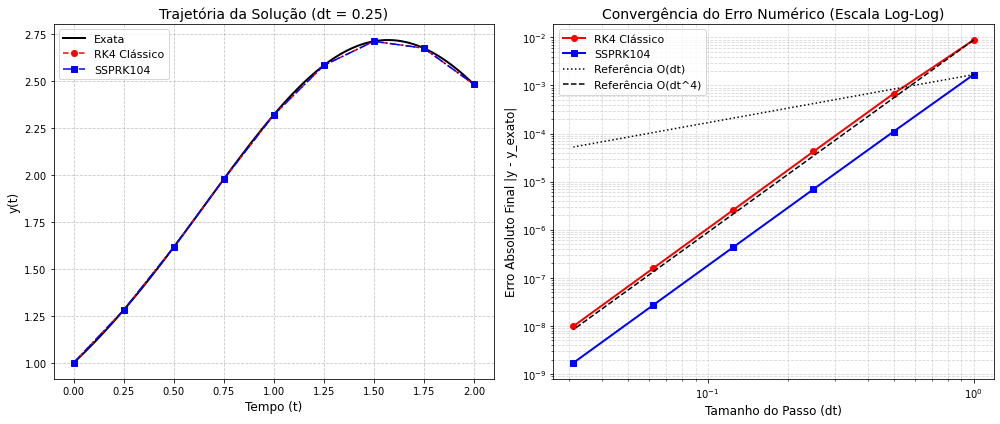

In [37]:
# ====================================================================
# EXTRAÇÃO DE DADOS PARA OS GRÁFICOS
# ====================================================================
t_inicial = 0.0
t_final = 2.0
passos_dt = [1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125]

U0_base, Lh, sol_exata = setup_teste_tempo_autonomo()
valor_exato_final = sol_exata(t_final)

erros_rk4 = []
erros_ssp = []


################### TABELA DE AVALIACAO DE ERRO #################
integradores = {'RK4 Clássico (Com correção)': RK4_Step, 'SSPRK(10,4) (Sem correção)': RKSSP104_Step}
for nome, integrador in integradores.items():
    print(f"\n=== Testando: {nome} ===")
    print(f"{'dt':<10} | {'Erro Absoluto':<15} | {'Ordem (p)':<10}")
    print("-" * 42)
    
    erro_anterior = None
    
    for dt_teste in passos_dt:
        U = [u.copy() for u in U0_base]
        t = t_inicial
        dt = dt_teste
        
        while t < t_final:
            if t + dt > t_final:
                dt = t_final - t
            U = integrador(U, t, dt, Lh)
            t += dt
            
        erro_atual = abs(U[0][0] - valor_exato_final)
        
        # Calculando a Ordem de Convergência p = log2(Erro_velho / Erro_novo)
        ordem = np.log2(erro_anterior / erro_atual) if erro_anterior is not None else 0.0
        
        print(f"{dt_teste:<10.5f} | {erro_atual:<15.2e} | {ordem:<10.2f}")
        erro_anterior = erro_atual

# Coletando os erros para o Log-Log
for dt_teste in passos_dt:
    # RK4
    U_rk4 = [u.copy() for u in U0_base]
    t = t_inicial
    dt = dt_teste
    while t < t_final:
        if t + dt > t_final: dt = t_final - t
        U_rk4 = RK4_Step(U_rk4, t, dt, Lh)
        t += dt
    erros_rk4.append(abs(U_rk4[0][0] - valor_exato_final))
    
    # SSP104
    U_ssp = [u.copy() for u in U0_base]
    t = t_inicial
    dt = dt_teste
    while t < t_final:
        if t + dt > t_final: dt = t_final - t
        U_ssp = RKSSP104_Step(U_ssp, t, dt, Lh)
        t += dt
    erros_ssp.append(abs(U_ssp[0][0] - valor_exato_final))

# Coletando trajetórias visuais com dt = 0.5
t_traj = t_inicial
dt_traj = 0.25
U_rk4_traj = [u.copy() for u in U0_base]
U_ssp_traj = [u.copy() for u in U0_base]
hist_t = [t_traj]
hist_rk4 = [U_rk4_traj[0][0]]
hist_ssp = [U_ssp_traj[0][0]]

while t_traj < t_final:
    if t_traj + dt_traj > t_final: dt_traj = t_final - t_traj
    U_rk4_traj = RK4_Step(U_rk4_traj, t_traj, dt_traj, Lh)
    U_ssp_traj = RKSSP104_Step(U_ssp_traj, t_traj, dt_traj, Lh)
    t_traj += dt_traj
    hist_t.append(t_traj)
    hist_rk4.append(U_rk4_traj[0][0])
    hist_ssp.append(U_ssp_traj[0][0])

# ====================================================================
# PLOTAGEM DOS GRÁFICOS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- GRÁFICO 1: Trajetória Visual ---
t_plot = np.linspace(t_inicial, t_final, 100)
ax1.plot(t_plot, sol_exata(t_plot), 'k-', linewidth=2, label='Exata')
ax1.plot(hist_t, hist_rk4, 'ro--', markersize=6, label='RK4 Clássico')
ax1.plot(hist_t, hist_ssp, 'bs-.', markersize=6, label='SSPRK104')
ax1.set_title(f"Trajetória da Solução (dt = {dt_traj})", fontsize=14)
ax1.set_xlabel('Tempo (t)', fontsize=12)
ax1.set_ylabel('y(t)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(fontsize=11)

# --- GRÁFICO 2: Análise de Convergência (Log-Log) ---
ax2.loglog(passos_dt, erros_rk4, 'ro-', markersize=6, linewidth=2, label='RK4 Clássico')
ax2.loglog(passos_dt, erros_ssp, 'bs-', markersize=6, linewidth=2, label='SSPRK104')

# Linhas de referência de inclinação (1ª Ordem e 4ª Ordem)
ref_ordem1 = [erros_ssp[0] * (dt / passos_dt[0])**1.0 for dt in passos_dt]
ref_ordem4 = [erros_rk4[0] * (dt / passos_dt[0])**4.0 for dt in passos_dt]
ax2.loglog(passos_dt, ref_ordem1, 'k:', linewidth=1.5, label='Referência O(dt)')
ax2.loglog(passos_dt, ref_ordem4, 'k--', linewidth=1.5, label='Referência O(dt^4)')

ax2.set_title('Convergência do Erro Numérico (Escala Log-Log)', fontsize=14)
ax2.set_xlabel('Tamanho do Passo (dt)', fontsize=12)
ax2.set_ylabel('Erro Absoluto Final |y - y_exato|', fontsize=12)
ax2.grid(True, which="both", linestyle='--', alpha=0.5)
ax2.legend(fontsize=11)

# Ajuste de layout e exibição
plt.tight_layout()
plt.show()